# Value at Risk (VaR) Models — Lecture Notes, Code, and Real-World Finance Cases

This notebook is organized as:
1. lecture explanation
2. runnable code
3. a final real-world finance section

It is based on the uploaded MIT lecture on Value at Risk (VaR) Models.


## 1) Lecture summary and intuition

### 1.1 Risk management mission

The lecture starts from a practical risk-management goal: management should understand the bank's risk profile and avoid unpleasant surprises from concentrated exposures.

### 1.2 What VaR is trying to measure

VaR focuses on a tail-loss threshold. For example:
- 95% VaR is a loss threshold exceeded about 5% of the time
- 99% VaR is a stricter loss threshold exceeded about 1% of the time

VaR is usually reported as a positive loss amount.

### 1.3 Why we use returns instead of price levels

Financial price levels often behave roughly like random walks, so returns are usually more stable inputs for risk measurement.

Simple return:

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

Log return:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

For daily VaR, either definition can work if used consistently.

### 1.4 One-asset parametric VaR

Standard workflow:
1. collect prices
2. compute returns
3. estimate return variance
4. take the square root to get volatility
5. multiply volatility by a tail z-score and by position size

Common one-sided z-scores:
- 95%: $z \approx 1.645$
- 99%: $z \approx 2.33$

For a long position of value $V$,

$$
\mathrm{VaR}_{\alpha} = z_{\alpha}\,\sigma\,V
$$

### 1.5 Caveats from the lecture

The lecture warns that:
- sign matters for long versus short positions
- one-sided and two-sided intervals are different
- bad data can distort VaR
- simple parametric VaR can understate extreme moves

### 1.6 Fixed income VaR and DV01

For bonds, we usually track yield changes, but losses arise through price sensitivity. A lecture-style approximation is

$$
\mathrm{VaR} \approx z_{\alpha}\,\sigma_y\times \text{DV01-adjusted exposure}
$$

Conceptually:
- estimate yield volatility
- convert yield shocks into price shocks with DV01 or PV01
- compute the resulting loss

### 1.7 Portfolio VaR with variance-covariance

For an exposure vector $w$ and covariance matrix $\Sigma$,

$$
\sigma_p^2 = w^\top \Sigma w
$$

so portfolio VaR becomes

$$
\mathrm{VaR}_{\alpha} = z_{\alpha}\sqrt{w^\top \Sigma w}
$$

This is the classical variance-covariance approach.

### 1.8 Correlation and diversification

Portfolio risk is not just the sum of standalone risks. Correlation matters, and diversification helps when assets are not perfectly correlated. The lecture also notes that correlations can become unstable during market stress.

### 1.9 Exponential weighting

The slides discuss exponential weighting, which puts more weight on recent observations. A common EWMA recursion is

$$
\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2
$$

with $\lambda$ often set near 0.94 for daily data.

### 1.10 Historical simulation

Historical simulation applies past shocks to today's portfolio, computes hypothetical P&L, ranks those outcomes, and reads off the desired tail percentile.

### 1.11 Monte Carlo VaR

Monte Carlo VaR simulates many scenarios from an estimated distribution, reprices the portfolio under each scenario, and then takes the required loss quantile.

### 1.12 Backtesting

Backtesting compares previous-day VaR with next-day realized P&L. If a 99% VaR model is well calibrated, exceptions should be rare over a long sample.



## 2) Setup

This notebook uses market data from `yfinance` when internet is available.  
If you run it locally and a package is missing, install the dependencies in the next cell.


In [ ]:

# Uncomment if needed
# %pip install yfinance pandas numpy matplotlib scipy statsmodels


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
import yfinance as yf



## 3) Helper functions

We will build reusable functions for:

- downloading adjusted prices
- computing simple or log returns
- one-asset parametric VaR
- portfolio variance-covariance VaR
- EWMA covariance
- historical simulation VaR
- Monte Carlo VaR
- backtesting


In [8]:

def download_prices(tickers, start="2020-01-01", end=None, auto_adjust=True):
    """Download adjusted daily prices from Yahoo Finance."""
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=auto_adjust,
        progress=False
    )
    if isinstance(data.columns, pd.MultiIndex):
        if "Close" in data.columns.get_level_values(0):
            prices = data["Close"].copy()
        else:
            prices = data.xs(data.columns.levels[0][0], axis=1, level=0)
    else:
        prices = data.copy()
    if isinstance(prices, pd.Series):
        prices = prices.to_frame(name=tickers if isinstance(tickers, str) else tickers[0])
    return prices.dropna(how="all")


def compute_returns(prices, method="log"):
    """Compute returns from price dataframe."""
    if method == "log":
        rets = np.log(prices / prices.shift(1))
    elif method == "simple":
        rets = prices.pct_change()
    else:
        raise ValueError("method must be 'log' or 'simple'")
    return rets.dropna(how="all")


def z_score(confidence=0.99):
    """One-sided z-score for a confidence level."""
    return norm.ppf(confidence)


def parametric_var_one_asset(position_value, returns, confidence=0.99):
    """Variance-covariance VaR for a single asset using volatility of returns."""
    sigma = returns.std(ddof=1)
    z = z_score(confidence)
    var_value = z * sigma * abs(position_value)
    return {
        "confidence": confidence,
        "z_score": z,
        "volatility": sigma,
        "VaR": var_value
    }


def portfolio_var_vcv(exposures, cov_matrix, confidence=0.99):
    w = np.asarray(exposures, dtype=float)
    cov_matrix = np.asarray(cov_matrix, dtype=float)

    sigma2 = w @ cov_matrix @ w
    sigma = np.sqrt(max(sigma2, 0.0))
    z = z_score(confidence)

    return {
        "confidence": confidence,
        "z_score": z,
        "portfolio_std": sigma,
        "VaR": z * sigma
    }


def ewma_covariance(returns, lam=0.94):
    """EWMA covariance matrix."""
    returns = returns.dropna().copy()
    n, k = returns.shape
    S = returns.cov().values
    for i in range(1, n):
        x = returns.iloc[i - 1].values.reshape(-1, 1)
        S = lam * S + (1 - lam) * (x @ x.T)
    return pd.DataFrame(S, index=returns.columns, columns=returns.columns)


def historical_var_from_portfolio_returns(portfolio_returns, portfolio_value=1.0, confidence=0.99):
    """Historical simulation VaR from portfolio returns."""
    alpha = 1 - confidence
    q = np.quantile(portfolio_returns.dropna(), alpha)
    return abs(q) * abs(portfolio_value)


def historical_var_from_asset_returns(asset_returns, exposures, confidence=0.99):
    """Historical simulation VaR from asset returns and exposure vector."""
    pnl = asset_returns.mul(exposures, axis=1).sum(axis=1)
    alpha = 1 - confidence
    q = np.quantile(pnl.dropna(), alpha)
    return {
        "confidence": confidence,
        "historical_VaR": abs(q),
        "pnl_series": pnl
    }


def monte_carlo_var(mu, cov, exposures, n_sims=20000, confidence=0.99, random_state=42):
    """Monte Carlo VaR under multivariate normal shocks."""
    rng = np.random.default_rng(random_state)
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    exposures = np.asarray(exposures, dtype=float)
    shocks = rng.multivariate_normal(mean=mu, cov=cov, size=n_sims)
    pnl = shocks @ exposures
    alpha = 1 - confidence
    q = np.quantile(pnl, alpha)
    return {
        "confidence": confidence,
        "monte_carlo_VaR": abs(q),
        "simulated_pnl": pd.Series(pnl, name="simulated_pnl")
    }


def var_backtest(pnl_series, var_series):
    """Simple VaR exception backtest.

    Convention:
    - pnl_series: realized daily P&L (positive = gain, negative = loss)
    - var_series: positive VaR amount
    Exception if loss exceeds VaR, i.e. pnl < -VaR
    """
    df = pd.DataFrame({"PnL": pnl_series, "VaR": var_series}).dropna()
    df["exception"] = df["PnL"] < -df["VaR"]
    exception_rate = df["exception"].mean()
    return df, exception_rate



## 4) One-asset VaR example

We start with a simple equity case.  
This directly mirrors the lecture logic:

- get prices
- turn prices into returns
- estimate volatility
- multiply by a z-score and position size


In [3]:

ticker = "AAPL"
start_date = "2020-01-01"

prices_1 = download_prices(ticker, start=start_date)
returns_1 = compute_returns(prices_1, method="log").squeeze()

position_value = 1_000_000  # example: $1,000,000 long position

var_95 = parametric_var_one_asset(position_value, returns_1, confidence=0.95)
var_99 = parametric_var_one_asset(position_value, returns_1, confidence=0.99)

pd.DataFrame([var_95, var_99])


,confidence,z_score,volatility,VaR
0,0.95,1.644854,0.019834,32623.687313
1,0.99,2.326348,0.019834,46140.303539


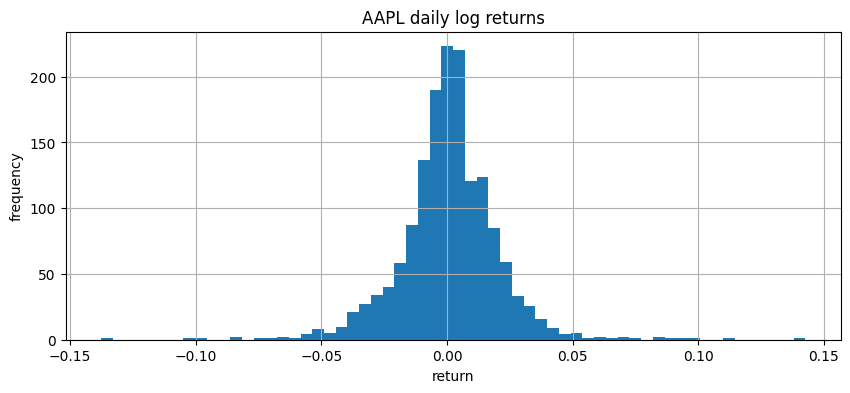

In [4]:

fig, ax = plt.subplots(figsize=(10, 4))
returns_1.hist(bins=60, ax=ax)
ax.set_title(f"{ticker} daily log returns")
ax.set_xlabel("return")
ax.set_ylabel("frequency")
plt.show()



### Interpretation
This is the cleanest VaR setup, but it also has the strongest assumptions:

- returns are treated as approximately normal
- volatility is assumed stable enough to summarize risk
- the position is treated as linear in the asset return

This is often acceptable for a first-pass risk dashboard, but it can underestimate tail events.


## 5) Fixed income intuition with DV01

The lecture explains that fixed-income VaR should be tied to yield sensitivity, not just price return.

We will:
- price a simple coupon bond
- compute DV01 numerically
- use yield volatility to translate rate moves into approximate price risk

A common approximation is

$$
\mathrm{VaR} \approx z_{\alpha}\,\sigma_y\times \text{DV01-adjusted exposure}
$$

This section is meant to show the idea clearly rather than exactly reproduce vendor bond analytics.


In [5]:

def bond_price(face, coupon_rate, ytm, maturity_years, freq=2):
    """Plain-vanilla bond price."""
    periods = int(maturity_years * freq)
    c = face * coupon_rate / freq
    y = ytm / freq
    cashflows = np.repeat(c, periods)
    cashflows[-1] += face
    times = np.arange(1, periods + 1)
    return np.sum(cashflows / (1 + y) ** times)


def dv01(face, coupon_rate, ytm, maturity_years, freq=2):
    """Approximate DV01 = price change for +1 bp yield move."""
    p0 = bond_price(face, coupon_rate, ytm, maturity_years, freq)
    p_up = bond_price(face, coupon_rate, ytm + 0.0001, maturity_years, freq)
    return p_up - p0  # usually negative


face = 1_000_000
coupon_rate = 0.045
ytm = 0.04644
maturity = 10

price0 = bond_price(face, coupon_rate, ytm, maturity)
bond_dv01 = dv01(face, coupon_rate, ytm, maturity)

summary_bond = pd.DataFrame({
    "metric": ["price", "DV01"],
    "value": [price0, bond_dv01]
})
summary_bond


,metric,value
0,price,988584.748915
1,DV01,-786.917741


In [6]:

# Example fixed-income VaR using yield volatility
yield_vol_bp = 8.5  # example: 8.5 bps daily volatility
confidence = 0.99
z = z_score(confidence)

# Approximate VaR in dollars:
# VaR ≈ z * daily yield vol in bps * |DV01|
bond_var_99 = z * yield_vol_bp * abs(bond_dv01)

print(f"Approximate 99% daily bond VaR: ${bond_var_99:,.2f}")


Approximate 99% daily bond VaR: $15,560.48



### Interpretation
This matches the lecture's message:

- for equities, VaR is often based directly on **price return volatility**
- for bonds, VaR is often based on **yield volatility × sensitivity**

In practice, rates desks manage exposures using **DV01/PV01** because it directly maps yield shocks into P&L.


## 6) Portfolio variance-covariance VaR

Now we extend the analysis to multiple assets.

The core matrix formula is

$$
\sigma_p^2 = w^\top \Sigma w
$$

and the corresponding parametric portfolio VaR is

$$
\mathrm{VaR}_{\alpha} = z_{\alpha}\sqrt{w^\top \Sigma w}
$$

We will use a small multi-asset portfolio with:
- `SPY` for US equity
- `TLT` for long-duration Treasuries
- `GLD` for gold
- `EEM` for emerging markets


In [9]:

tickers = ["SPY", "TLT", "GLD", "EEM"]
prices = download_prices(tickers, start="2020-01-01")
returns = compute_returns(prices, method="log").dropna()

# Example dollar exposures
exposures = pd.Series({
    "SPY": 1_500_000,
    "TLT": 750_000,
    "GLD": 500_000,
    "EEM": 400_000
})

cov_matrix = returns.cov().loc[exposures.index, exposures.index]
corr_matrix = returns.corr().loc[exposures.index, exposures.index]

vcv_result_95 = portfolio_var_vcv(exposures.values, cov_matrix.values, confidence=0.95)
vcv_result_99 = portfolio_var_vcv(exposures.values, cov_matrix.values, confidence=0.99)

print("Covariance matrix")
display(cov_matrix)

print("\nCorrelation matrix")
display(corr_matrix)

print("\nPortfolio VaR results")
display(pd.DataFrame([vcv_result_95, vcv_result_99]))


Covariance matrix


,SPY,TLT,GLD,EEM
SPY,0.000168,-0.000016,0.000019,0.000136
TLT,-0.000016,0.000113,0.000024,-0.000012
GLD,0.000019,0.000024,0.000130,0.000043
EEM,0.000136,-0.000012,0.000043,0.000192



Correlation matrix


,SPY,TLT,GLD,EEM
SPY,1.000000,-0.115574,0.131191,0.757635
TLT,-0.115574,1.000000,0.201608,-0.078588
GLD,0.131191,0.201608,1.000000,0.270242
EEM,0.757635,-0.078588,0.270242,1.000000



Portfolio VaR results


,confidence,z_score,portfolio_std,VaR
0,0.95,1.644854,26256.17217,43187.560024
1,0.99,2.326348,26256.17217,61080.990308


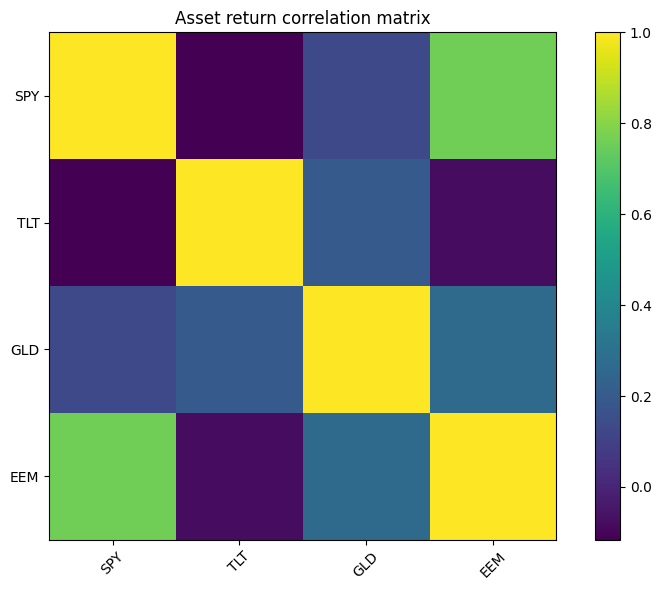

In [10]:

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Asset return correlation matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



### Interpretation
This approach is fast and scalable, which is why it is popular in daily risk systems.  
But it assumes:

- portfolio P&L is approximately linear in small shocks
- covariance structure is informative about near-future risk
- tails are not too different from a normal approximation

Those assumptions can break during stress.



## 7) EWMA volatility and covariance

The lecture discusses **exponential weighting** as a way to give more importance to recent observations.

Below we compare standard sample covariance with EWMA covariance.


In [11]:

ewma_cov = ewma_covariance(returns, lam=0.94).loc[exposures.index, exposures.index]

ewma_var_99 = portfolio_var_vcv(exposures.values, ewma_cov.values, confidence=0.99)
sample_var_99 = portfolio_var_vcv(exposures.values, cov_matrix.values, confidence=0.99)

comparison = pd.DataFrame([
    {"method": "sample_covariance", **sample_var_99},
    {"method": "ewma_covariance", **ewma_var_99},
])
comparison


,method,confidence,z_score,portfolio_std,VaR
0,sample_covariance,0.99,2.326348,26256.17217,61080.990308
1,ewma_covariance,0.99,2.326348,34693.02425,80708.043209



### Interpretation
EWMA usually reacts faster to recent volatility spikes.  
That can be useful when a calm period suddenly turns unstable, but it may also make VaR more sensitive to very recent noise.



## 8) Historical simulation VaR

Historical simulation is one of the lecture's key methods because it avoids imposing a normal distribution on returns.

We apply historical daily return shocks directly to today's portfolio exposures.


In [12]:

hist_result_95 = historical_var_from_asset_returns(returns[exposures.index], exposures, confidence=0.95)
hist_result_99 = historical_var_from_asset_returns(returns[exposures.index], exposures, confidence=0.99)

pd.DataFrame([
    {"confidence": 0.95, "historical_VaR": hist_result_95["historical_VaR"]},
    {"confidence": 0.99, "historical_VaR": hist_result_99["historical_VaR"]},
])


,confidence,historical_VaR
0,0.95,40448.323288
1,0.99,69965.851675


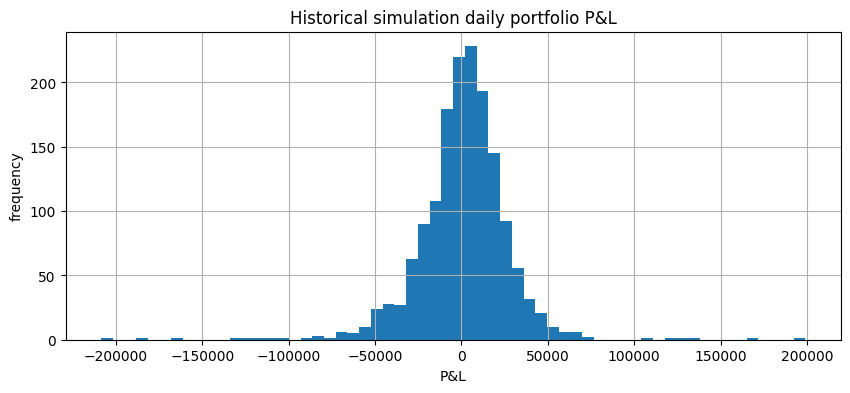

1% quantile P&L: -69965.8516749994


In [13]:

pnl_hist = hist_result_99["pnl_series"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
pnl_hist.hist(bins=60, ax=ax)
ax.set_title("Historical simulation daily portfolio P&L")
ax.set_xlabel("P&L")
ax.set_ylabel("frequency")
plt.show()

print("1% quantile P&L:", np.quantile(pnl_hist, 0.01))



### Interpretation
Historical simulation is appealing because it naturally reflects:

- skewness
- fat tails
- real co-movements seen in past market data

But it only knows the past.  
If your historical window missed a crisis that could happen again, historical VaR may still underestimate risk.



## 9) Monte Carlo VaR

The lecture later turns to Monte Carlo simulation, where we:

1. estimate a joint shock distribution
2. generate many correlated scenarios
3. revalue portfolio P&L
4. measure the tail loss

Below we use a simple multivariate normal engine.


In [14]:

mu = returns[exposures.index].mean().values
cov = returns[exposures.index].cov().values

mc_result_95 = monte_carlo_var(mu, cov, exposures.values, n_sims=20000, confidence=0.95, random_state=42)
mc_result_99 = monte_carlo_var(mu, cov, exposures.values, n_sims=50000, confidence=0.99, random_state=42)

pd.DataFrame([
    {"confidence": 0.95, "monte_carlo_VaR": mc_result_95["monte_carlo_VaR"]},
    {"confidence": 0.99, "monte_carlo_VaR": mc_result_99["monte_carlo_VaR"]},
])


,confidence,monte_carlo_VaR
0,0.95,42700.863847
1,0.99,61096.421254


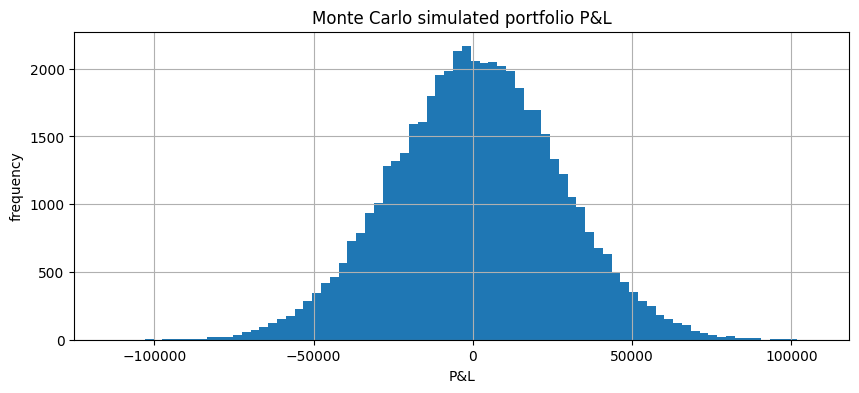

In [15]:

fig, ax = plt.subplots(figsize=(10, 4))
mc_result_99["simulated_pnl"].hist(bins=80, ax=ax)
ax.set_title("Monte Carlo simulated portfolio P&L")
ax.set_xlabel("P&L")
ax.set_ylabel("frequency")
plt.show()



### Interpretation
Monte Carlo becomes much more valuable when:

- the portfolio contains **options or other non-linear instruments**
- you want to simulate **custom regimes**
- you want to include **stress-like assumptions**
- simple normal approximations are too crude

The trade-off is more modeling work and more computation time.



## 10) Compare VaR methods side by side


In [16]:

comparison_df = pd.DataFrame({
    "Method": ["Parametric VCV (99%)", "EWMA VCV (99%)", "Historical (99%)", "Monte Carlo (99%)"],
    "VaR": [
        vcv_result_99["VaR"],
        ewma_var_99["VaR"],
        hist_result_99["historical_VaR"],
        mc_result_99["monte_carlo_VaR"],
    ]
})
comparison_df


,Method,VaR
0,Parametric VCV (99%),61080.990308
1,EWMA VCV (99%),80708.043209
2,Historical (99%),69965.851675
3,Monte Carlo (99%),61096.421254


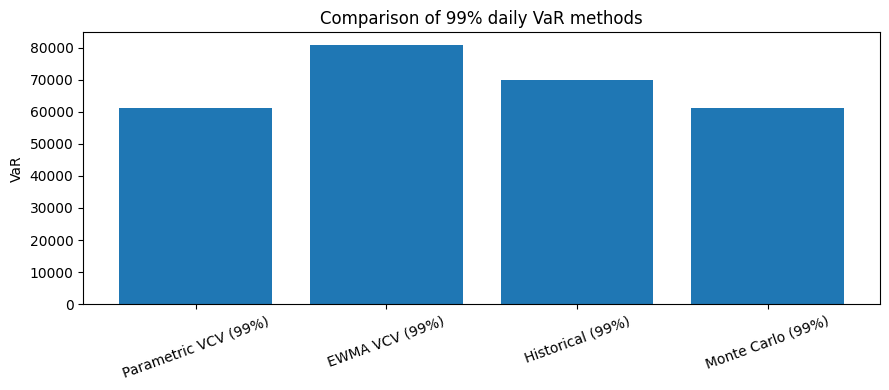

In [17]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(comparison_df["Method"], comparison_df["VaR"])
ax.set_title("Comparison of 99% daily VaR methods")
ax.set_ylabel("VaR")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()



## 11) Backtesting

The lecture stresses that VaR by itself is not enough.  
A good risk process compares predicted VaR with realized next-day P&L.

Below is a simple rolling parametric VaR backtest for the same portfolio.


In [18]:

portfolio_returns = returns[exposures.index].mul(exposures, axis=1).sum(axis=1)
rolling_window = 252
confidence = 0.99
z = z_score(confidence)

rolling_sigma = portfolio_returns.rolling(rolling_window).std(ddof=1)
rolling_var = z * rolling_sigma

# Realized next-day P&L aligned with today's VaR
bt_df, exception_rate = var_backtest(
    pnl_series=portfolio_returns.shift(-1),
    var_series=rolling_var
)

print(f"Observed exception rate: {exception_rate:.2%}")
print(f"Expected exception rate for 99% VaR: {1-confidence:.2%}")
bt_df.head()


Observed exception rate: 2.35%
Expected exception rate for 99% VaR: 1.00%


,PnL,VaR,exception
Date,,,
2020-12-31,-7912.171537,88360.673449,False
2021-01-04,15685.396599,88371.738095,False
2021-01-05,-18197.009465,88392.825410,False
2021-01-06,18083.774071,88434.435084,False
2021-01-07,-863.009655,88465.741266,False


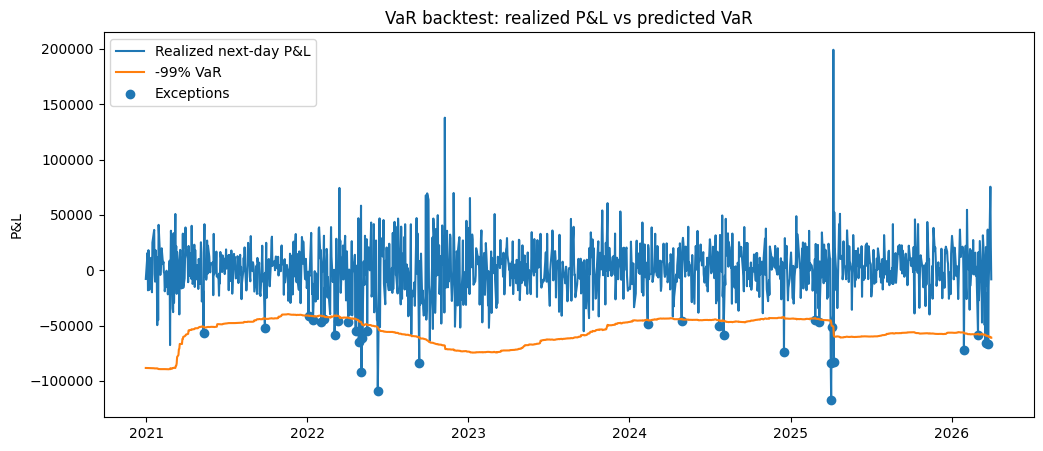

In [19]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bt_df.index, bt_df["PnL"], label="Realized next-day P&L")
ax.plot(bt_df.index, -bt_df["VaR"], label="-99% VaR")
ax.scatter(
    bt_df.index[bt_df["exception"]],
    bt_df.loc[bt_df["exception"], "PnL"],
    label="Exceptions"
)
ax.set_title("VaR backtest: realized P&L vs predicted VaR")
ax.set_ylabel("P&L")
ax.legend()
plt.show()



### Interpretation
If exceptions are much more frequent than expected, possible explanations include:

- volatility regime shift
- poor distributional assumptions
- stale correlations
- non-linearity not captured by the model
- position changes not aligned with the VaR engine

Backtesting is one of the most practical ways to judge whether a VaR framework is still credible.


## 12) Short conclusion

This notebook follows the lecture's logic:
- start from returns and volatility
- build one-asset VaR
- adjust fixed income with DV01 intuition
- scale to portfolios with covariance matrices
- compare parametric VaR with historical simulation and Monte Carlo
- check model quality with backtesting

In practice, VaR should be read together with stress testing, scenario analysis, and sound judgment.


## 13) Real-world finance cases

### Case 1: Equity trading desk
A trader holds names such as AAPL, MSFT, NVDA, and SPY. Daily VaR gives a quick estimate of how much could be lost on a normal bad day at 95% or 99% confidence.

### Case 2: Bond or treasury book
A rates desk manages government bonds, swaps, or duration overlays. DV01-based VaR translates yield volatility into potential price losses and helps set risk limits.

### Case 3: Multi-asset portfolio
A portfolio manager combines equities, bonds, gold, and emerging-market exposure. Covariance-matrix VaR captures diversification benefits and concentration risk.

### Case 4: Risk dashboard for management
A bank or asset manager can compute rolling VaR every day, compare it with limits, and track whether current risk is increasing or decreasing.

### Case 5: Model validation and backtesting
Risk teams compare predicted VaR with realized P&L. Too many exceptions may indicate stale volatility estimates, unstable correlations, or weak distributional assumptions.

### Case 6: Scenario-based decision support
VaR alone is not enough. In real workflows it is usually paired with stress scenarios such as rate shocks, equity crashes, FX moves, or liquidity stress.


## 14) Real-world implementation notes

When you run this notebook with live data, you can adapt it to:
- a single stock position
- a portfolio of ETFs
- a bond portfolio using yield data and DV01
- a desk-level P&L backtest
- a management risk report that compares current VaR with recent history

This keeps the final section practical and directly connected to day-to-day finance work.
